# Faster R-CNN for Global Wheat Detection
Assignment-4 style notebook with `tqdm` progress bars, detailed logging, and training graphs.

In [ ]:
# !pip install torch torchvision pandas matplotlib pillow tqdm


In [3]:
import time
from pathlib import Path

import pandas as pd
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from faster_rcnn_wheat import (
    WheatDataset,
    build_split,
    collate_fn,
    evaluate_inference_count,
    get_model,
    save_prediction_preview,
    save_training_plots,
    set_seed,
    train_one_epoch,
)


In [ ]:
DATA_DIR = Path(r"C:\\wheat-detection\\data")
OUTPUT_DIR = Path("outputs_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 5
BATCH_SIZE = 5
NUM_WORKERS = 4
VAL_RATIO = 0.2
SEED = 444
LR = 1e-4
WEIGHT_DECAY = 1e-4
SCORE_THRESHOLD = 0.4

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [5]:
csv_path = DATA_DIR / "train.csv"
image_dir = DATA_DIR / "train"
assert csv_path.exists(), f"Missing {csv_path}"
assert image_dir.exists(), f"Missing {image_dir}"

df = pd.read_csv(csv_path)
image_ids = df["image_id"].unique().tolist()
split = build_split(image_ids, val_ratio=VAL_RATIO, seed=SEED)

train_ds = WheatDataset(df, image_dir=image_dir, image_ids=split.train_ids, augment=True)
val_ds = WheatDataset(df, image_dir=image_dir, image_ids=split.val_ids, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

print(f"Train images: {len(train_ds)} | Val images: {len(val_ds)}")


Train images: 2699 | Val images: 674


In [6]:
model = get_model(num_classes=1).to(device)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = StepLR(optimizer, step_size=4, gamma=0.1)


In [7]:
history = []
best_loss = float("inf")

for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
    epoch_start = time.time()
    train_losses = train_one_epoch(model, train_loader, optimizer, device)
    scheduler.step()

    avg_pred, avg_gt = evaluate_inference_count(model, val_loader, device, SCORE_THRESHOLD)
    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "loss_total": train_losses.get("loss_total"),
        "loss_classifier": train_losses.get("loss_classifier"),
        "loss_box_reg": train_losses.get("loss_box_reg"),
        "loss_objectness": train_losses.get("loss_objectness"),
        "loss_rpn_box_reg": train_losses.get("loss_rpn_box_reg"),
        "val_avg_pred_boxes": avg_pred,
        "val_avg_gt_boxes": avg_gt,
        "lr": current_lr,
        "epoch_time_sec": epoch_time,
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | loss_total={row['loss_total']:.4f} | "
        f"loss_cls={row['loss_classifier']:.4f} | loss_box={row['loss_box_reg']:.4f} | "
        f"loss_obj={row['loss_objectness']:.4f} | loss_rpn={row['loss_rpn_box_reg']:.4f} | "
        f"val_pred={avg_pred:.2f} | val_gt={avg_gt:.2f} | lr={current_lr:.2e} | time={epoch_time:.1f}s"
    )

    if row["loss_total"] < best_loss:
        best_loss = row["loss_total"]
        torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pt")

torch.save(model.state_dict(), OUTPUT_DIR / "last_model.pt")


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/540 [00:11<?, ?it/s]

Val:   0%|          | 0/135 [00:11<?, ?it/s]

Epoch 01/5 | loss_total=0.8976 | loss_cls=0.2472 | loss_box=0.4861 | loss_obj=0.0823 | loss_rpn=0.0820 | val_pred=49.08 | val_gt=43.51 | lr=1.00e-04 | time=230.8s


Train:   0%|          | 0/540 [00:10<?, ?it/s]

...

Val:   0%|          | 0/135 [00:12<?, ?it/s]

Epoch 04/5 | loss_total=0.7160 | loss_cls=0.1952 | loss_box=0.4129 | loss_obj=0.0437 | loss_rpn=0.0643 | val_pred=43.07 | val_gt=43.51 | lr=1.00e-05 | time=253.2s


Train:   0%|          | 0/540 [00:12<?, ?it/s]

Val:   0%|          | 0/135 [00:11<?, ?it/s]

Epoch 05/5 | loss_total=0.6562 | loss_cls=0.1788 | loss_box=0.3884 | loss_obj=0.0318 | loss_rpn=0.0572 | val_pred=43.96 | val_gt=43.51 | lr=1.00e-05 | time=258.4s


In [8]:
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
save_training_plots(history_df, OUTPUT_DIR)

preview_path = OUTPUT_DIR / "val_prediction_preview.png"
save_prediction_preview(model, val_ds, device, preview_path, SCORE_THRESHOLD, sample_index=0)

print("Saved:", OUTPUT_DIR / "training_history.csv")
print("Saved:", OUTPUT_DIR / "loss_curves.png")
print("Saved:", OUTPUT_DIR / "val_box_count_trend.png")
print("Saved:", OUTPUT_DIR / "epoch_runtime.png")
print("Saved:", preview_path)
history_df


Saved: outputs_notebook\training_history.csv
Saved: outputs_notebook\loss_curves.png
Saved: outputs_notebook\val_box_count_trend.png
Saved: outputs_notebook\epoch_runtime.png
Saved: outputs_notebook\val_prediction_preview.png


,epoch,loss_total,loss_classifier,loss_box_reg,loss_objectness,loss_rpn_box_reg,val_avg_pred_boxes,val_avg_gt_boxes,lr,epoch_time_sec
0,1,0.897621,0.247192,0.486148,0.082316,0.081965,49.081602,43.505935,0.00010,230.817316
1,2,0.776501,0.214195,0.437152,0.054678,0.070476,43.318991,43.505935,0.00010,222.371120
2,3,0.743064,0.202665,0.424831,0.048618,0.066950,43.166172,43.505935,0.00010,272.783149
3,4,0.715984,0.195217,0.412855,0.043650,0.064262,43.074184,43.505935,0.00001,253.184440
4,5,0.656237,0.178791,0.388401,0.031812,0.057234,43.955490,43.505935,0.00001,258.358810


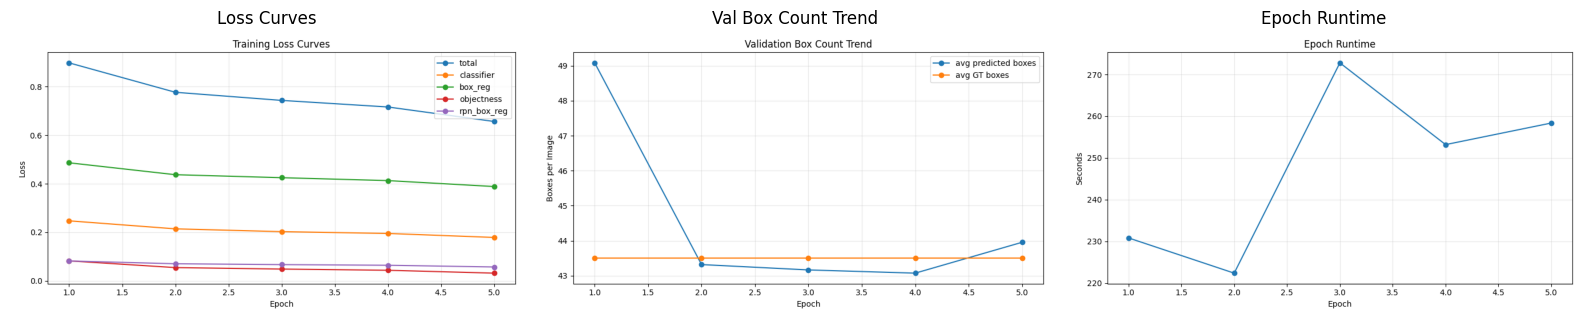

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(Image.open(OUTPUT_DIR / "loss_curves.png"))
axes[0].set_title("Loss Curves")
axes[0].axis("off")

axes[1].imshow(Image.open(OUTPUT_DIR / "val_box_count_trend.png"))
axes[1].set_title("Val Box Count Trend")
axes[1].axis("off")

axes[2].imshow(Image.open(OUTPUT_DIR / "epoch_runtime.png"))
axes[2].set_title("Epoch Runtime")
axes[2].axis("off")
plt.tight_layout()
plt.show()


CLI version:
`python faster_rcnn_wheat.py --data-dir "C:\\path\\to\\global-wheat-detection" --epochs 8 --batch-size 2`